In [2]:
import pandas as pd
import numpy as np
nav = pd.read_csv('02_nav_history_cleaned.csv')
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
fund_info = pd.read_csv('01_fund_master_cleaned.csv')
perf = pd.read_csv('07_scheme_performance_cleaned.csv')
txn = pd.read_csv('08_investor_transactions_cleaned.csv')
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])
holdings = pd.read_csv('09_portfolio_holdings_cleaned.csv')
print("Setup complete:", nav.shape, fund_info.shape, perf.shape, txn.shape, holdings.shape)

Setup complete: (64320, 4) (40, 15) (40, 19) (32778, 13) (322, 8)


### ***Historical VaR (95%) and CVaR***

In [3]:
var_cvar_results = []
for code in nav['amfi_code'].unique():
    returns = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_cvar_results.append({'amfi_code': code,'var_95': var_95,'cvar_95': cvar_95})
var_cvar_df = pd.DataFrame(var_cvar_results)
var_cvar_df = var_cvar_df.merge(fund_info[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']], on='amfi_code', how='left')
var_cvar_df = var_cvar_df.sort_values('var_95').reset_index(drop=True)
print(var_cvar_df.head(10))
var_cvar_df.to_csv('var_cvar_report.csv', index=False)
print("Saved var_cvar_report.csv")


   amfi_code    var_95   cvar_95  \
0     101207 -0.023915 -0.030289   
1     119095 -0.023284 -0.029690   
2     119599 -0.023155 -0.030163   
3     118634 -0.022810 -0.029940   
4     149324 -0.021520 -0.028573   
5     119598 -0.021502 -0.028444   
6     119094 -0.016997 -0.022375   
7     120842 -0.016950 -0.021251   
8     100033 -0.016902 -0.021850   
9     102886 -0.016857 -0.021771   

                                         scheme_name  \
0             ABSL Small Cap Fund - Regular - Growth   
1             Axis Small Cap Fund - Regular - Growth   
2          SBI Small Cap Fund - Direct Plan - Growth   
3     Nippon India Small Cap Fund - Regular - Growth   
4              DSP Small Cap Fund - Regular - Growth   
5         SBI Small Cap Fund - Regular Plan - Growth   
6                Axis Midcap Fund - Regular - Growth   
7      Kotak Emerging Equity Fund - Regular - Growth   
8  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
9                UTI Mid Cap Fund - Regular

**VaR/CVaR Insight:** Small Cap funds dominate the highest tail-risk positions in the dataset. The six worst VaR 95% positions are all Small Cap schemes, led by ABSL Small Cap Fund at -2.39%, followed by Axis Small Cap at -2.33% and SBI Small Cap Direct at -2.32%. Their CVaR values range from approximately -2.84% to -3.03%, indicating that the average loss within the worst 5% of trading days is substantially deeper than the VaR threshold. Mid Cap funds form the next group of high-tail-risk schemes, with VaR values around -1.69% to -1.70%. Overall, the results indicate that Small Cap funds exhibit the greatest downside tail risk in this dataset.

### ***Rolling 90-day Sharpe***

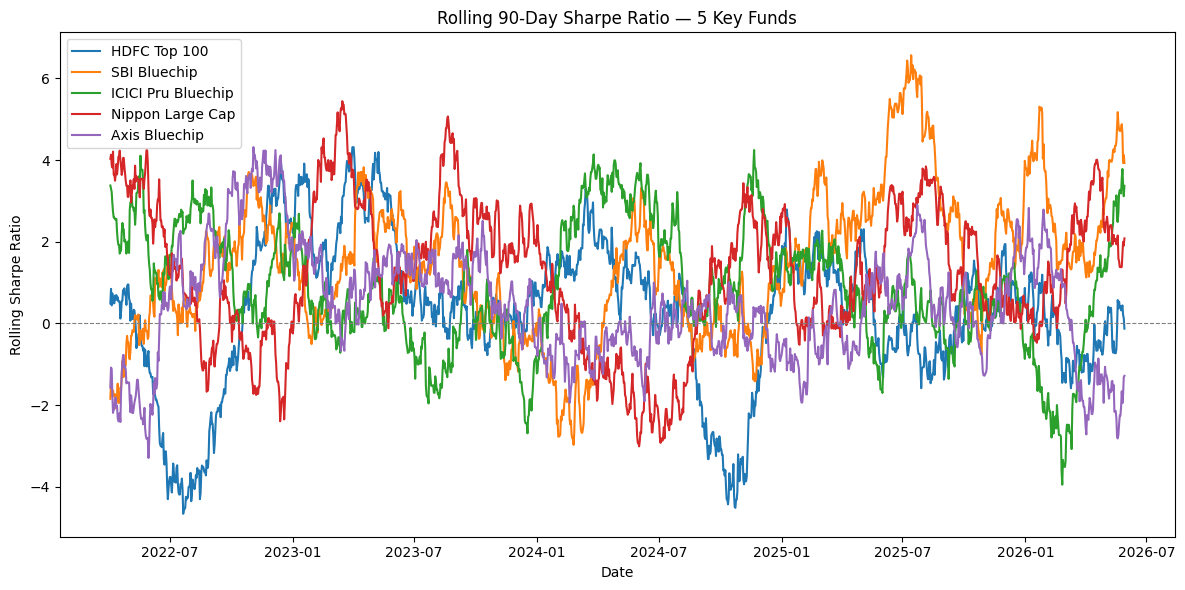

Saved rolling_sharpe_chart.png


In [13]:
import matplotlib.pyplot as plt
key_funds = {
    100016: 'HDFC Top 100',
    119551: 'SBI Bluechip',
    120503: 'ICICI Pru Bluechip',
    118632: 'Nippon Large Cap',
    119092: 'Axis Bluechip'
}
fig, ax = plt.subplots(figsize=(12, 6))
for code, name in key_funds.items():
    fund_data = (nav[nav['amfi_code'] == code].sort_values('date').copy())
    fund_data['rolling_sharpe'] = (fund_data['daily_return'].rolling(90).mean()/ fund_data['daily_return'].rolling(90).std()) * np.sqrt(252)
    ax.plot(fund_data['date'],fund_data['rolling_sharpe'],label=name)
ax.axhline(0,color='gray',linewidth=0.8,linestyle='--')
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png',dpi=150)
plt.show()
print("Saved rolling_sharpe_chart.png")

**Rolling Sharpe Insight:** The 90-day Sharpe ratios fluctuate substantially across the five selected large-cap funds, with periods of both positive and negative risk-adjusted performance. SBI Bluechip shows particularly strong positive Sharpe periods during 2025, while HDFC Top 100 experiences pronounced negative periods around mid-2022 and late 2024. Nippon Large Cap also shows substantial variation, including strong positive periods in 2022–2023 and weaker periods during 2024. The variation demonstrates that risk-adjusted performance changes materially over time rather than remaining constant across market conditions.

### ***Investor Cohort Analysis***

In [5]:
investor_first_txn = txn.groupby('investor_id')['transaction_date'].min().reset_index()
investor_first_txn['cohort_year'] = investor_first_txn['transaction_date'].dt.year
investor_first_txn = investor_first_txn.rename(columns={'transaction_date': 'first_txn_date'})
txn_cohort = txn.merge(investor_first_txn[['investor_id', 'cohort_year']], on='investor_id', how='left')
sip_txn = txn_cohort[txn_cohort['transaction_type'] == 'SIP']
avg_sip = sip_txn.groupby('cohort_year')['amount_inr'].mean().reset_index(name='avg_sip_amount')
total_invested = txn_cohort.groupby('cohort_year')['amount_inr'].sum().reset_index(name='total_invested')
fund_pref = txn_cohort.merge(fund_info[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
top_fund = fund_pref.groupby(['cohort_year', 'scheme_name']).size().reset_index(name='count')
top_fund = top_fund.sort_values('count', ascending=False).drop_duplicates('cohort_year')
top_fund = top_fund[['cohort_year', 'scheme_name']].rename(columns={'scheme_name': 'top_fund_preference'})
cohort_summary = avg_sip.merge(total_invested, on='cohort_year').merge(top_fund, on='cohort_year')
cohort_summary = cohort_summary.sort_values('cohort_year').reset_index(drop=True)
print(cohort_summary)

   cohort_year  avg_sip_amount  total_invested  \
0         2024    10996.885825      3491125187   
1         2025    13505.209581        30455243   

                                 top_fund_preference  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


**Investor Cohort Insight:**  2025 investors have a higher average SIP amount (₹13,505) than 2024 investors (₹10,997). However, the 2024 cohort has much higher total investment (₹349.1 Cr) compared with 2025 (₹3.05 Cr), mainly because they started earlier. The preferred funds also differ: 2024 investors preferred Mirae Asset Emerging Bluechip, while 2025 investors preferred SBI Small Cap Direct.

### ***SIP Continuity Analysis***

In [6]:
sip_only = txn[txn['transaction_type'] == 'SIP'].copy()
sip_only = sip_only.sort_values(['investor_id', 'transaction_date'])
sip_counts = sip_only.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index
sip_eligible = sip_only[sip_only['investor_id'].isin(eligible_investors)].copy()
sip_eligible['gap_days'] = sip_eligible.groupby('investor_id')['transaction_date'].diff().dt.days
continuity = sip_eligible.groupby('investor_id')['gap_days'].mean().reset_index(name='avg_gap_days')
continuity['at_risk'] = continuity['avg_gap_days'] > 35
print(f"Investors with 6+ SIP transactions: {len(continuity)}")
print(f"At-risk investors (avg gap > 35 days): {continuity['at_risk'].sum()}")
print(continuity.head(10))

Investors with 6+ SIP transactions: 1362
At-risk investors (avg gap > 35 days): 1332
  investor_id  avg_gap_days  at_risk
0   INV000004     85.400000     True
1   INV000008     70.400000     True
2   INV000010     64.800000     True
3   INV000011     40.166667     True
4   INV000012     57.000000     True
5   INV000013     55.333333     True
6   INV000014     75.333333     True
7   INV000023     58.571429     True
8   INV000028     93.600000     True
9   INV000029     60.666667     True


**SIP Continuity Insight:** Among 1,362 investors with at least 6 SIP transactions, 1,332 investors (97.8%) are classified as at-risk because their average gap between SIP transactions is greater than 35 days. This indicates a significant SIP continuity issue in the dataset.

***Sector HHI Concentration***

In [11]:
holdings_equity = holdings.merge(fund_info[['amfi_code', 'category']],on='amfi_code',how='left')
holdings_equity = holdings_equity[holdings_equity['category'] == 'Equity']
hhi = (holdings_equity.groupby('amfi_code')['weight_pct'].apply(lambda x: ((x / 100) ** 2).sum()).reset_index(name='hhi'))
hhi = hhi.merge(fund_info[['amfi_code', 'scheme_name', 'sub_category']],on='amfi_code',how='left')
hhi = hhi.sort_values('hhi',ascending=False).reset_index(drop=True)
print(hhi)

    amfi_code       hhi                                        scheme_name  \
0      119092  0.206448              Axis Bluechip Fund - Regular - Growth   
1      101207  0.200700             ABSL Small Cap Fund - Regular - Growth   
2      119599  0.174751          SBI Small Cap Fund - Direct Plan - Growth   
3      102885  0.174709         UTI Nifty 50 Index Fund - Regular - Growth   
4      118632  0.168298     Nippon India Large Cap Fund - Regular - Growth   
5      148568  0.167930  Mirae Asset Emerging Bluechip Fund - Regular -...   
6      120505  0.157570           ICICI Pru Midcap Fund - Regular - Growth   
7      120506  0.153794  ICICI Pru Value Discovery Fund - Regular - Growth   
8      125498  0.152414  HDFC Mid-Cap Opportunities Fund - Direct - Growth   
9      120841  0.149680             Kotak Bluechip Fund - Regular - Growth   
10     148569  0.149396      Mirae Asset Tax Saver Fund - Regular - Growth   
11     100033  0.147592  HDFC Mid-Cap Opportunities Fund - Regul

### ***Simple Fund Recommender***

In [9]:
recommender_code = '''
"""
recommender.py
---------------
Simple fund recommender: input risk appetite, output top 3 funds by Sharpe ratio
within matching risk_grade.
"""
import pandas as pd
def recommend_funds(risk_appetite, perf_path="07_scheme_performance_cleaned.csv"):
    """
    risk_appetite: 'Low', 'Moderate', or 'High'
    Returns top 3 funds by Sharpe ratio within matching risk_grade.
    """
    perf = pd.read_csv(perf_path)
    risk_map = {"Low": ["Low"],"Moderate": ["Moderate", "Moderately High"],"High": ["High", "Very High"],   }
    if risk_appetite not in risk_map:
        raise ValueError("risk_appetite must be 'Low', 'Moderate', or 'High'")
    matched = perf[perf["risk_grade"].isin(risk_map[risk_appetite])]
    top3 = matched.sort_values("sharpe_ratio", ascending=False).head(3)
    print(f"\\nTop 3 funds for '{risk_appetite}' risk appetite:\\n")
    print(top3[["scheme_name", "fund_house", "risk_grade", "sharpe_ratio", "return_3yr_pct"]].to_string(index=False))
    return top3
if __name__ == "__main__":
    for appetite in ["Low", "Moderate", "High"]:
        recommend_funds(appetite)
'''
with open('recommender.py', 'w') as f:
    f.write(recommender_code)
print("Saved recommender.py")
exec(recommender_code.replace('if __name__ == "__main__":', 'if True:'))

Saved recommender.py

Top 3 funds for 'Low' risk appetite:

                             scheme_name               fund_house risk_grade  sharpe_ratio  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF        Low          7.68            7.68
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF        Low          6.18            6.18
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF        Low          5.14            5.14

Top 3 funds for 'Moderate' risk appetite:

                                  scheme_name          fund_house risk_grade  sharpe_ratio  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund   Moderate          1.06           14.84
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF   Moderate          1.06           14.81
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF   Moderate          1.03           14.41

Top 3 funds for 'High' risk appetite:

